DAU 분석
          date  dau
0   2026-04-01   96
1   2026-04-02  102
2   2026-04-03   84
3   2026-04-04  109
4   2026-04-05   79
5   2026-04-06   91
6   2026-04-07   94
7   2026-04-08  106
8   2026-04-09   98
9   2026-04-10  119
10  2026-04-11   70
11  2026-04-12   89
12  2026-04-13  116
13  2026-04-14  106


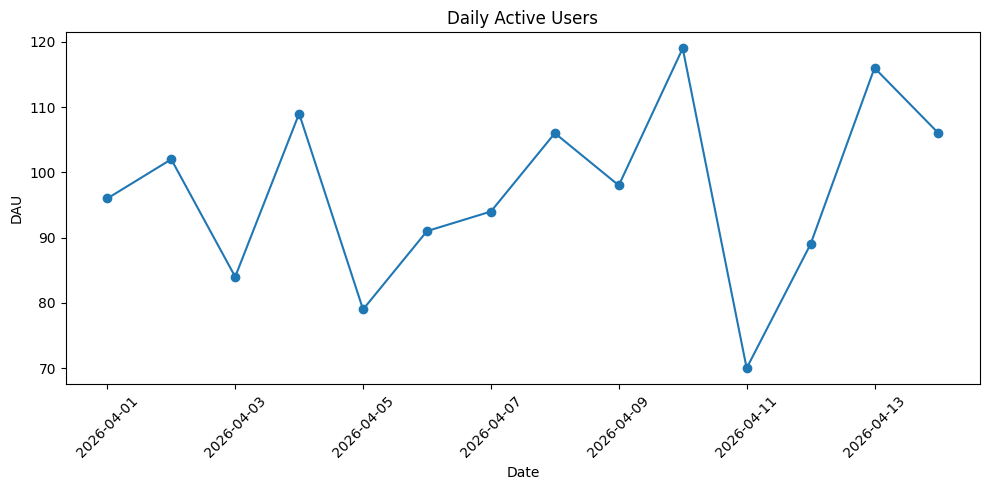


요일별 방문자 수
     weekday  unique_users
0     Monday           199
1    Tuesday           195
2  Wednesday           196
3   Thursday           194
4     Friday           200
5   Saturday           175
6     Sunday           166


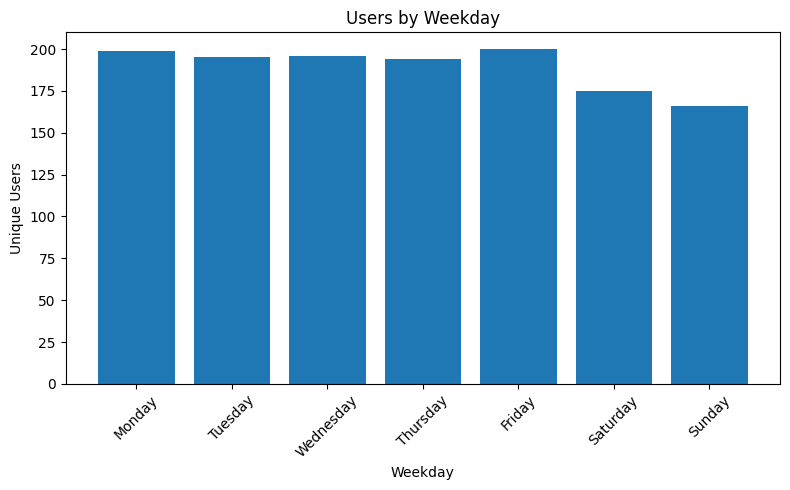


행동 유형별 평균 체류시간
  session_type  session_duration
0         cart        261.341246
1     purchase        255.349206
2    view_only        269.196739


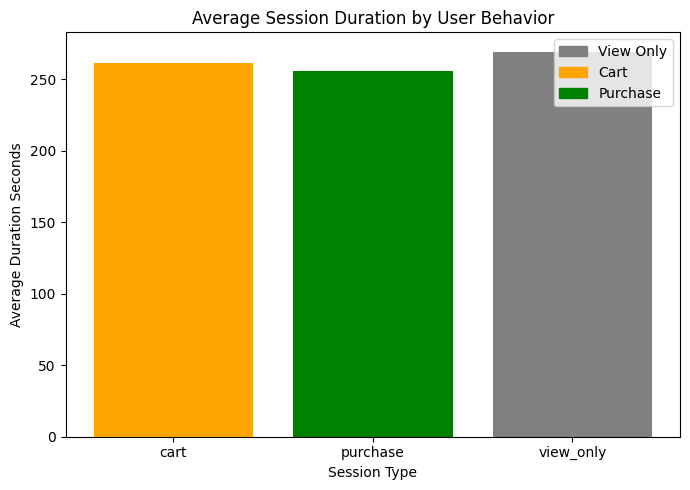


퍼널 분석
      stage  session_count  conversion_rate_from_view
0      view           1383                   1.000000
1      cart            463                   0.334779
2  purchase            126                   0.091106


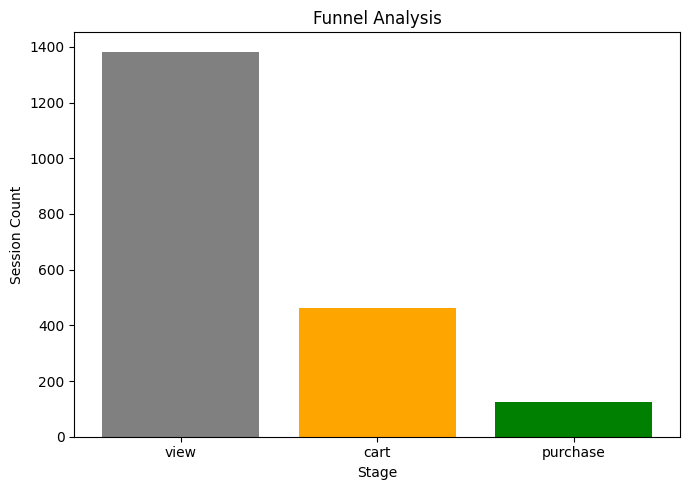


단계별 이탈률
               step  dropoff_rate
0      view_to_cart      0.665221
1  cart_to_purchase      0.727862


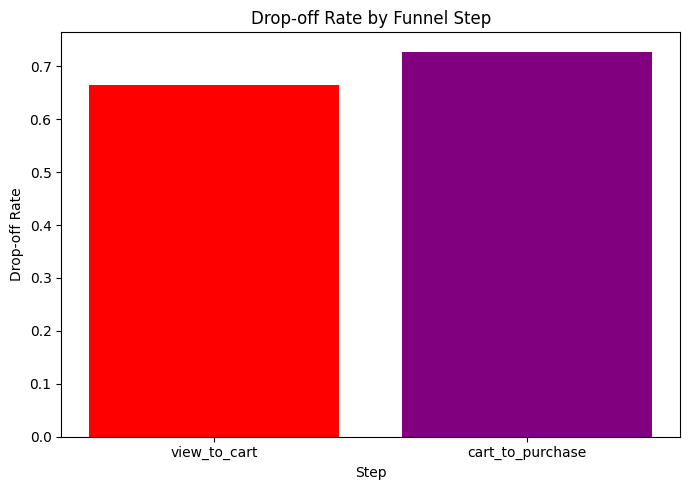


===== 핵심 요약 =====
가장 방문자가 많은 요일: Friday
view 세션 수: 1383
cart 세션 수: 463
purchase 세션 수: 126
view → cart 이탈률: 66.52%
cart → purchase 이탈률: 72.79%


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =========================
# 0) 데이터 불러오기
# =========================

df = pd.read_csv("mju_mock_data_2132.csv")

df["event_time"] = pd.to_datetime(df["event_time"])
df["date"] = df["event_time"].dt.date
df["weekday"] = df["event_time"].dt.day_name()

# =========================
# 1) 색상 설정
# =========================

behavior_color_map = {
    "view_only": "gray",
    "cart": "orange",
    "purchase": "green"
}

funnel_color_map = {
    "view": "gray",
    "cart": "orange",
    "purchase": "green"
}

drop_color_map = {
    "view_to_cart": "red",
    "cart_to_purchase": "purple"
}

# =========================
# 2) DAU 분석
# =========================

dau = df.groupby("date")["user_id"].nunique().reset_index()
dau.columns = ["date", "dau"]

print("DAU 분석")
print(dau)

plt.figure(figsize=(10, 5))
plt.plot(dau["date"], dau["dau"], marker="o")
plt.title("Daily Active Users")
plt.xlabel("Date")
plt.ylabel("DAU")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 3) 요일별 방문자 수
# =========================

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_users = (
    df.groupby("weekday")["user_id"]
    .nunique()
    .reindex(weekday_order)
    .reset_index()
)

weekday_users.columns = ["weekday", "unique_users"]

print("\n요일별 방문자 수")
print(weekday_users)

plt.figure(figsize=(8, 5))
plt.bar(weekday_users["weekday"], weekday_users["unique_users"])
plt.title("Users by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Unique Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 4) 세션별 체류시간 분석
# =========================

session_summary = df.groupby("user_session").agg(
    user_id=("user_id", "first"),
    session_duration=("session_duration", "first"),
    event_count=("event_type", "count"),
    first_event_time=("event_time", "min"),
    last_event_time=("event_time", "max")
).reset_index()

def classify_session(events):
    events = set(events)

    if "purchase" in events:
        return "purchase"
    elif "cart" in events:
        return "cart"
    else:
        return "view_only"

session_type = (
    df.groupby("user_session")["event_type"]
    .apply(classify_session)
    .reset_index()
)

session_type.columns = ["user_session", "session_type"]

session_summary = session_summary.merge(session_type, on="user_session")

duration_by_type = (
    session_summary.groupby("session_type")["session_duration"]
    .mean()
    .reset_index()
)

print("\n행동 유형별 평균 체류시간")
print(duration_by_type)

duration_colors = [
    behavior_color_map[x] for x in duration_by_type["session_type"]
]

plt.figure(figsize=(7, 5))
plt.bar(
    duration_by_type["session_type"],
    duration_by_type["session_duration"],
    color=duration_colors
)

plt.title("Average Session Duration by User Behavior")
plt.xlabel("Session Type")
plt.ylabel("Average Duration Seconds")

legend_items = [
    mpatches.Patch(color="gray", label="View Only"),
    mpatches.Patch(color="orange", label="Cart"),
    mpatches.Patch(color="green", label="Purchase")
]

plt.legend(handles=legend_items)
plt.tight_layout()
plt.show()

# =========================
# 5) 퍼널 분석
# =========================

session_events = df.groupby("user_session")["event_type"].apply(set)

view_count = session_events.apply(lambda x: "view" in x).sum()
cart_count = session_events.apply(lambda x: "cart" in x).sum()
purchase_count = session_events.apply(lambda x: "purchase" in x).sum()

funnel = pd.DataFrame({
    "stage": ["view", "cart", "purchase"],
    "session_count": [view_count, cart_count, purchase_count]
})

funnel["conversion_rate_from_view"] = funnel["session_count"] / view_count

print("\n퍼널 분석")
print(funnel)

funnel_colors = [
    funnel_color_map[x] for x in funnel["stage"]
]

plt.figure(figsize=(7, 5))
plt.bar(
    funnel["stage"],
    funnel["session_count"],
    color=funnel_colors
)

plt.title("Funnel Analysis")
plt.xlabel("Stage")
plt.ylabel("Session Count")
plt.tight_layout()
plt.show()

# =========================
# 6) 단계별 이탈률 계산
# =========================

view_to_cart_drop = 1 - (cart_count / view_count)
cart_to_purchase_drop = 1 - (purchase_count / cart_count)

dropoff = pd.DataFrame({
    "step": ["view_to_cart", "cart_to_purchase"],
    "dropoff_rate": [view_to_cart_drop, cart_to_purchase_drop]
})

print("\n단계별 이탈률")
print(dropoff)

drop_colors = [
    drop_color_map[x] for x in dropoff["step"]
]

plt.figure(figsize=(7, 5))
plt.bar(
    dropoff["step"],
    dropoff["dropoff_rate"],
    color=drop_colors
)

plt.title("Drop-off Rate by Funnel Step")
plt.xlabel("Step")
plt.ylabel("Drop-off Rate")
plt.tight_layout()
plt.show()

# =========================
# 7) 핵심 요약 출력
# =========================

best_weekday = weekday_users.sort_values(
    "unique_users",
    ascending=False
).iloc[0]

print("\n===== 핵심 요약 =====")
print(f"가장 방문자가 많은 요일: {best_weekday['weekday']}")
print(f"view 세션 수: {view_count}")
print(f"cart 세션 수: {cart_count}")
print(f"purchase 세션 수: {purchase_count}")
print(f"view → cart 이탈률: {view_to_cart_drop:.2%}")
print(f"cart → purchase 이탈률: {cart_to_purchase_drop:.2%}")

DAU 분석
            날짜  DAU
0   2026-04-01   96
1   2026-04-02  102
2   2026-04-03   84
3   2026-04-04  109
4   2026-04-05   79
5   2026-04-06   91
6   2026-04-07   94
7   2026-04-08  106
8   2026-04-09   98
9   2026-04-10  119
10  2026-04-11   70
11  2026-04-12   89
12  2026-04-13  116
13  2026-04-14  106


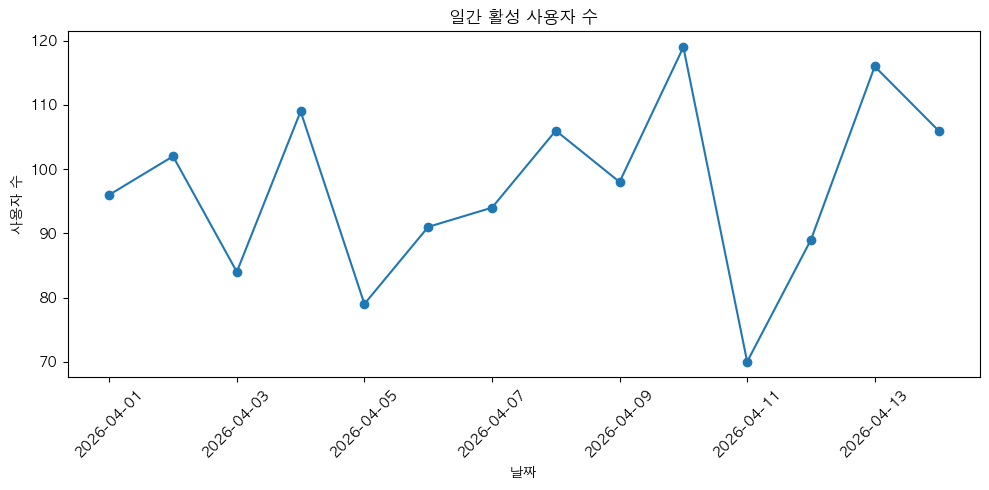


요일별 방문자 수
    요일  방문자 수
0  월요일    199
1  화요일    195
2  수요일    196
3  목요일    194
4  금요일    200
5  토요일    175
6  일요일    166


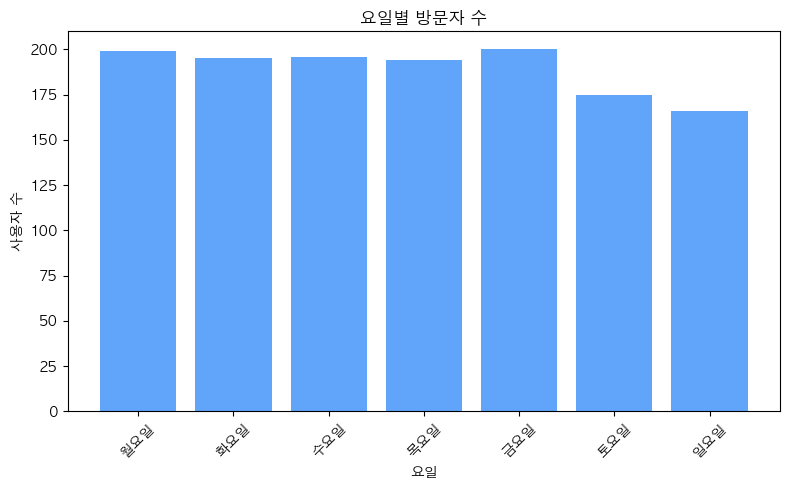


행동 유형별 평균 체류시간
  session_type session_type_kor  session_duration
0         cart          장바구니 세션        261.341246
1     purchase            구매 세션        255.349206
2    view_only         조회만 한 세션        269.196739


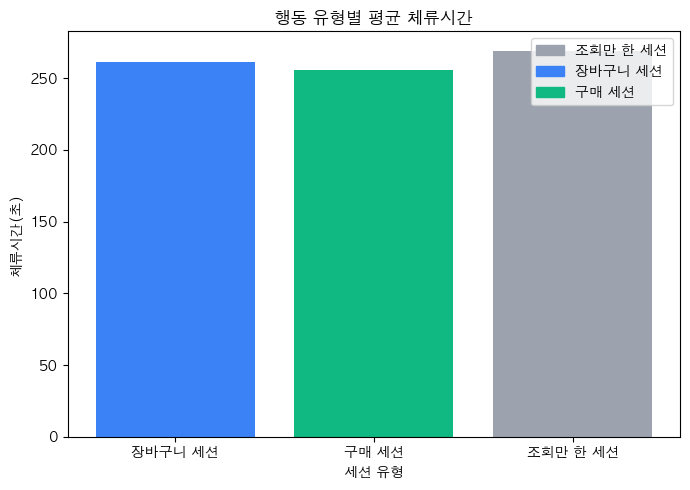


퍼널 분석
      stage     단계  세션 수  조회 대비 전환율
0      view  상품 조회  1383   1.000000
1      cart   장바구니   463   0.334779
2  purchase     구매   126   0.091106


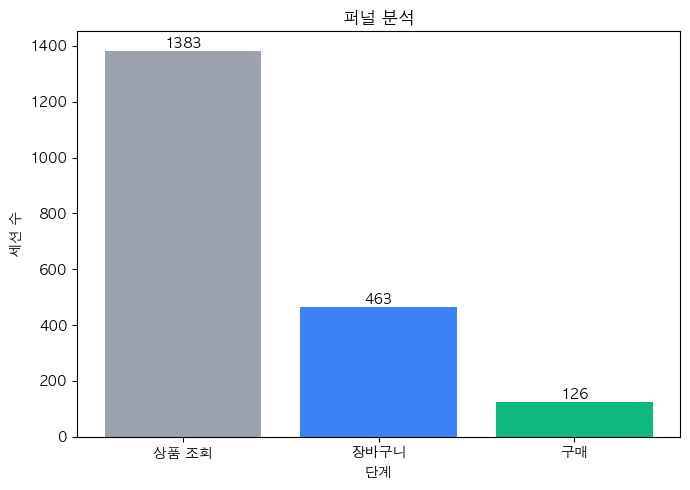


단계별 이탈률
               step            단계       이탈률
0      view_to_cart  상품 조회 → 장바구니  0.665221
1  cart_to_purchase     장바구니 → 구매  0.727862


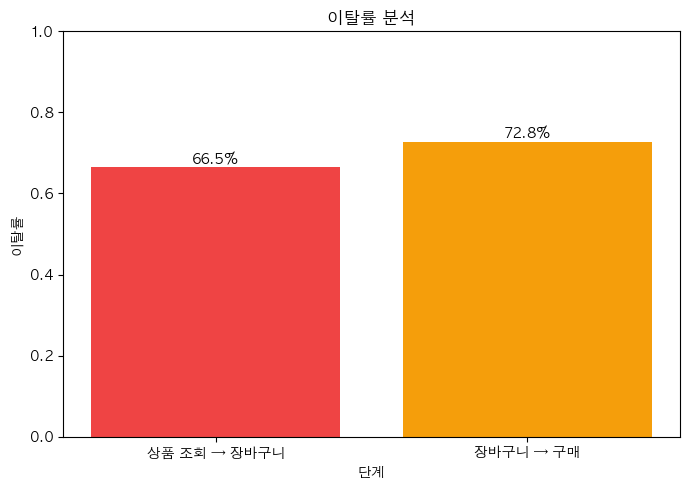


추가 KPI 분석
              지표             값
0       전체 이벤트 수  2.132000e+03
1         페이지뷰 수  1.383000e+03
2        전체 세션 수  1.383000e+03
3       전체 사용자 수  9.960000e+02
4   세션당 평균 이벤트 수  1.541576e+00
5            이탈률  6.652205e-01
6       장바구니 전환율  3.347795e-01
7         구매 전환율  9.110629e-02
8       장바구니 이탈률  7.278618e-01
9           총 매출  1.539000e+06
10           객단가  1.221429e+04
11          ARPU  1.545181e+03


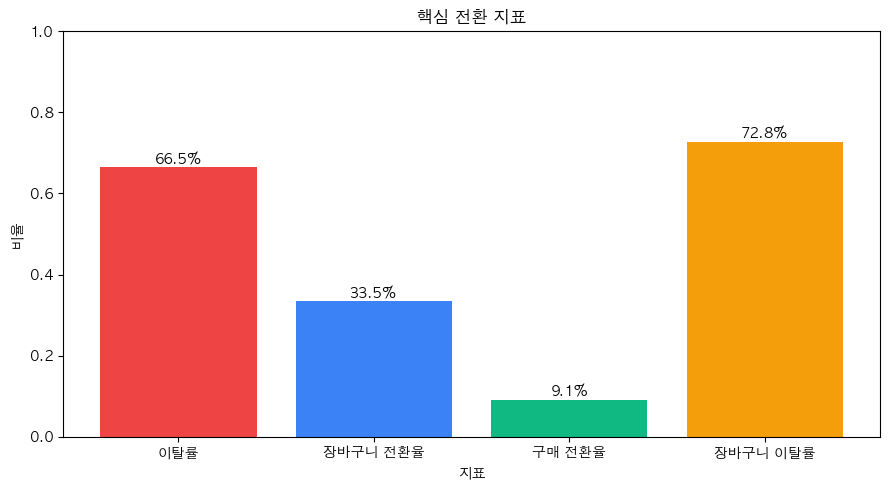


상품별 이벤트 분석
event_type  product_id   category_code  cart  purchase  remove_from_cart  \
0                 1001   admission_kit  33.0       7.0              11.0   
1                 1001         journal  28.0       4.0               9.0   
2                 1001  season_project  29.0       8.0              15.0   
3                 1001  spring_project  30.0      11.0              11.0   
4                 1002   admission_kit  27.0       7.0               7.0   
5                 1002         journal  29.0      10.0               9.0   
6                 1002  season_project  25.0       6.0               9.0   
7                 1002  spring_project  25.0       9.0               4.0   
8                 1003   admission_kit  25.0       8.0              15.0   
9                 1003         journal  23.0       5.0              13.0   
10                1003  season_project  34.0       8.0               9.0   
11                1003  spring_project  35.0       8.0               9.0   


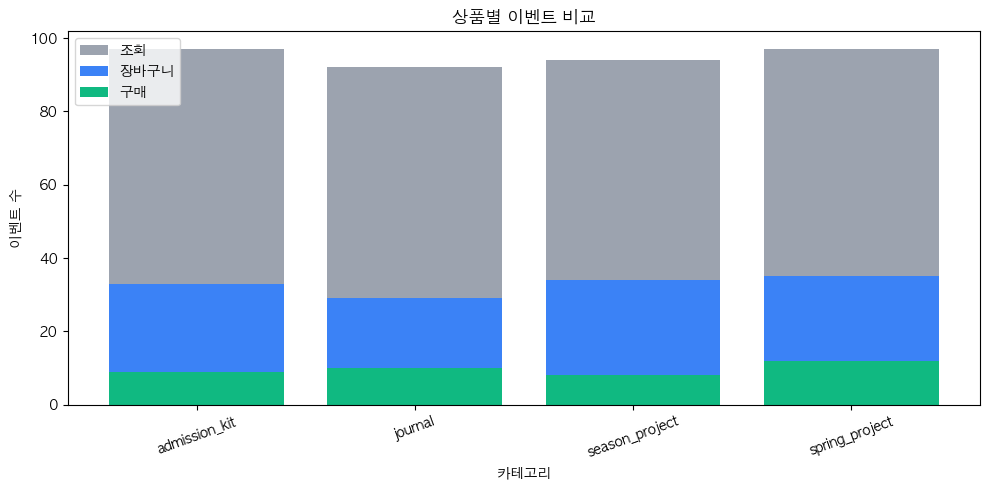


===== 핵심 요약 =====
가장 방문자가 많은 요일: 금요일
view 세션 수: 1383
cart 세션 수: 463
purchase 세션 수: 126
view → cart 이탈률: 66.52%
cart → purchase 이탈률: 72.79%
전체 이벤트 수: 2132
페이지뷰 수: 1383
전체 세션 수: 1383
전체 사용자 수: 996
평균 세션당 이벤트 수: 1.54
이탈률: 66.52%
장바구니 전환율: 33.48%
구매 전환율: 9.11%
장바구니 이탈률: 72.79%
총 매출: 1,539,000원
객단가: 12,214원
ARPU: 1,545원

===== 데이터 기반 의사결정 =====
- 이탈률이 높으므로 첫 화면 구성, 상품 썸네일, 상품 설명 개선이 필요함
- cart → purchase 단계의 이탈이 더 크므로 주문/결제 흐름 개선이 우선임
- 전체 구매 전환율이 낮으므로 구매 유도 배너, 추천 상품, 할인 정책 검토가 필요함
- 총 매출은 1,539,000원이며 유저당 평균 매출은 1,545원임


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =========================
# 0) 기본 설정
# =========================

plt.rcParams["font.family"] = "AppleGothic"   # Mac
# plt.rcParams["font.family"] = "Malgun Gothic"  # Windows
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("mju_mock_data_2132.csv")

df["event_time"] = pd.to_datetime(df["event_time"])
df["date"] = df["event_time"].dt.date
df["weekday"] = df["event_time"].dt.day_name()

weekday_kor_map = {
    "Monday": "월요일",
    "Tuesday": "화요일",
    "Wednesday": "수요일",
    "Thursday": "목요일",
    "Friday": "금요일",
    "Saturday": "토요일",
    "Sunday": "일요일"
}

df["weekday_kor"] = df["weekday"].map(weekday_kor_map)

# =========================
# 1) 색상 설정
# =========================

behavior_color_map = {
    "view_only": "#9CA3AF",
    "cart": "#3B82F6",
    "purchase": "#10B981"
}

funnel_color_map = {
    "view": "#9CA3AF",
    "cart": "#3B82F6",
    "purchase": "#10B981"
}

drop_color_map = {
    "view_to_cart": "#EF4444",
    "cart_to_purchase": "#F59E0B"
}

# =========================
# 2) DAU 분석
# =========================

dau = df.groupby("date")["user_id"].nunique().reset_index()
dau.columns = ["날짜", "DAU"]

print("DAU 분석")
print(dau)

plt.figure(figsize=(10, 5))
plt.plot(dau["날짜"], dau["DAU"], marker="o")
plt.title("일간 활성 사용자 수")
plt.xlabel("날짜")
plt.ylabel("사용자 수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 3) 요일별 방문자 수
# =========================

weekday_order_kor = [
    "월요일", "화요일", "수요일", "목요일",
    "금요일", "토요일", "일요일"
]

weekday_users = (
    df.groupby("weekday_kor")["user_id"]
    .nunique()
    .reindex(weekday_order_kor)
    .reset_index()
)

weekday_users.columns = ["요일", "방문자 수"]

print("\n요일별 방문자 수")
print(weekday_users)

plt.figure(figsize=(8, 5))
plt.bar(weekday_users["요일"], weekday_users["방문자 수"], color="#60A5FA")
plt.title("요일별 방문자 수")
plt.xlabel("요일")
plt.ylabel("사용자 수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 4) 세션별 체류시간 분석
# =========================

session_summary = df.groupby("user_session").agg(
    user_id=("user_id", "first"),
    session_duration=("session_duration", "first"),
    event_count=("event_type", "count"),
    first_event_time=("event_time", "min"),
    last_event_time=("event_time", "max")
).reset_index()

def classify_session(events):
    events = set(events)

    if "purchase" in events:
        return "purchase"
    elif "cart" in events:
        return "cart"
    else:
        return "view_only"

session_type = (
    df.groupby("user_session")["event_type"]
    .apply(classify_session)
    .reset_index()
)

session_type.columns = ["user_session", "session_type"]

session_summary = session_summary.merge(session_type, on="user_session")

session_type_kor_map = {
    "view_only": "조회만 한 세션",
    "cart": "장바구니 세션",
    "purchase": "구매 세션"
}

session_summary["session_type_kor"] = session_summary["session_type"].map(session_type_kor_map)

duration_by_type = (
    session_summary.groupby(["session_type", "session_type_kor"])["session_duration"]
    .mean()
    .reset_index()
)

print("\n행동 유형별 평균 체류시간")
print(duration_by_type)

duration_colors = [
    behavior_color_map[x] for x in duration_by_type["session_type"]
]

plt.figure(figsize=(7, 5))
plt.bar(
    duration_by_type["session_type_kor"],
    duration_by_type["session_duration"],
    color=duration_colors
)

plt.title("행동 유형별 평균 체류시간")
plt.xlabel("세션 유형")
plt.ylabel("체류시간(초)")

legend_items = [
    mpatches.Patch(color="#9CA3AF", label="조회만 한 세션"),
    mpatches.Patch(color="#3B82F6", label="장바구니 세션"),
    mpatches.Patch(color="#10B981", label="구매 세션")
]

plt.legend(handles=legend_items)
plt.tight_layout()
plt.show()

# =========================
# 5) 퍼널 분석
# =========================

session_events = df.groupby("user_session")["event_type"].apply(set)

view_count = session_events.apply(lambda x: "view" in x).sum()
cart_count = session_events.apply(lambda x: "cart" in x).sum()
purchase_count = session_events.apply(lambda x: "purchase" in x).sum()

funnel = pd.DataFrame({
    "stage": ["view", "cart", "purchase"],
    "단계": ["상품 조회", "장바구니", "구매"],
    "세션 수": [view_count, cart_count, purchase_count]
})

funnel["조회 대비 전환율"] = funnel["세션 수"] / view_count

print("\n퍼널 분석")
print(funnel)

funnel_colors = [
    funnel_color_map[x] for x in funnel["stage"]
]

plt.figure(figsize=(7, 5))
bars = plt.bar(
    funnel["단계"],
    funnel["세션 수"],
    color=funnel_colors
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )

plt.title("퍼널 분석")
plt.xlabel("단계")
plt.ylabel("세션 수")
plt.tight_layout()
plt.show()

# =========================
# 6) 단계별 이탈률 계산
# =========================

view_to_cart_drop = 1 - (cart_count / view_count)
cart_to_purchase_drop = 1 - (purchase_count / cart_count)

dropoff = pd.DataFrame({
    "step": ["view_to_cart", "cart_to_purchase"],
    "단계": ["상품 조회 → 장바구니", "장바구니 → 구매"],
    "이탈률": [view_to_cart_drop, cart_to_purchase_drop]
})

print("\n단계별 이탈률")
print(dropoff)

drop_colors = [
    drop_color_map[x] for x in dropoff["step"]
]

plt.figure(figsize=(7, 5))
bars = plt.bar(
    dropoff["단계"],
    dropoff["이탈률"],
    color=drop_colors
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1%}",
        ha="center",
        va="bottom"
    )

plt.title("이탈률 분석")
plt.xlabel("단계")
plt.ylabel("이탈률")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# =========================
# 7) 추가 KPI 분석
# =========================

page_views = df[df["event_type"] == "view"].shape[0]
total_events = df.shape[0]
total_sessions = df["user_session"].nunique()
total_users = df["user_id"].nunique()

avg_events_per_session = (
    df.groupby("user_session")["event_type"]
    .count()
    .mean()
)

bounce_sessions = session_events.apply(lambda x: x == {"view"}).sum()
bounce_rate = bounce_sessions / total_sessions

add_to_cart_rate = cart_count / view_count
purchase_conversion_rate = purchase_count / view_count
cart_abandonment_rate = 1 - (purchase_count / cart_count)

revenue = df[df["event_type"] == "purchase"]["price"].sum()
avg_order_value = revenue / purchase_count
arpu = revenue / total_users

kpi_summary = pd.DataFrame({
    "지표": [
        "전체 이벤트 수",
        "페이지뷰 수",
        "전체 세션 수",
        "전체 사용자 수",
        "세션당 평균 이벤트 수",
        "이탈률",
        "장바구니 전환율",
        "구매 전환율",
        "장바구니 이탈률",
        "총 매출",
        "객단가",
        "ARPU"
    ],
    "값": [
        total_events,
        page_views,
        total_sessions,
        total_users,
        avg_events_per_session,
        bounce_rate,
        add_to_cart_rate,
        purchase_conversion_rate,
        cart_abandonment_rate,
        revenue,
        avg_order_value,
        arpu
    ]
})

print("\n추가 KPI 분석")
print(kpi_summary)

rate_metrics = pd.DataFrame({
    "지표": [
        "이탈률",
        "장바구니 전환율",
        "구매 전환율",
        "장바구니 이탈률"
    ],
    "비율": [
        bounce_rate,
        add_to_cart_rate,
        purchase_conversion_rate,
        cart_abandonment_rate
    ]
})

rate_colors = [
    "#EF4444",
    "#3B82F6",
    "#10B981",
    "#F59E0B"
]

plt.figure(figsize=(9, 5))
bars = plt.bar(
    rate_metrics["지표"],
    rate_metrics["비율"],
    color=rate_colors
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1%}",
        ha="center",
        va="bottom"
    )

plt.title("핵심 전환 지표")
plt.xlabel("지표")
plt.ylabel("비율")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# =========================
# 8) 상품별 조회 / 장바구니 / 구매 분석
# =========================

product_event = (
    df.groupby(["product_id", "category_code", "event_type"])
    .size()
    .reset_index(name="count")
)

product_pivot = product_event.pivot_table(
    index=["product_id", "category_code"],
    columns="event_type",
    values="count",
    fill_value=0
).reset_index()

for col in ["view", "cart", "purchase", "remove_from_cart"]:
    if col not in product_pivot.columns:
        product_pivot[col] = 0

product_pivot["장바구니 전환율"] = product_pivot["cart"] / product_pivot["view"]
product_pivot["구매 전환율"] = product_pivot["purchase"] / product_pivot["view"]

print("\n상품별 이벤트 분석")
print(product_pivot)

plt.figure(figsize=(10, 5))
plt.bar(
    product_pivot["category_code"],
    product_pivot["view"],
    color="#9CA3AF",
    label="조회"
)
plt.bar(
    product_pivot["category_code"],
    product_pivot["cart"],
    color="#3B82F6",
    label="장바구니"
)
plt.bar(
    product_pivot["category_code"],
    product_pivot["purchase"],
    color="#10B981",
    label="구매"
)

plt.title("상품별 이벤트 비교")
plt.xlabel("카테고리")
plt.ylabel("이벤트 수")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 9) 핵심 요약 출력
# =========================

best_weekday = weekday_users.sort_values(
    "방문자 수",
    ascending=False
).iloc[0]

print("\n===== 핵심 요약 =====")
print(f"가장 방문자가 많은 요일: {best_weekday['요일']}")
print(f"view 세션 수: {view_count}")
print(f"cart 세션 수: {cart_count}")
print(f"purchase 세션 수: {purchase_count}")
print(f"view → cart 이탈률: {view_to_cart_drop:.2%}")
print(f"cart → purchase 이탈률: {cart_to_purchase_drop:.2%}")
print(f"전체 이벤트 수: {total_events}")
print(f"페이지뷰 수: {page_views}")
print(f"전체 세션 수: {total_sessions}")
print(f"전체 사용자 수: {total_users}")
print(f"평균 세션당 이벤트 수: {avg_events_per_session:.2f}")
print(f"이탈률: {bounce_rate:.2%}")
print(f"장바구니 전환율: {add_to_cart_rate:.2%}")
print(f"구매 전환율: {purchase_conversion_rate:.2%}")
print(f"장바구니 이탈률: {cart_abandonment_rate:.2%}")
print(f"총 매출: {revenue:,.0f}원")
print(f"객단가: {avg_order_value:,.0f}원")
print(f"ARPU: {arpu:,.0f}원")

# =========================
# 10) 데이터 기반 의사결정
# =========================

print("\n===== 데이터 기반 의사결정 =====")

if bounce_rate > 0.5:
    print("- 이탈률이 높으므로 첫 화면 구성, 상품 썸네일, 상품 설명 개선이 필요함")
else:
    print("- 이탈률이 상대적으로 낮아 초기 탐색 흐름은 양호한 편임")

if view_to_cart_drop > cart_to_purchase_drop:
    print("- view → cart 단계의 이탈이 더 크므로 상품 매력도와 상세 정보 개선이 우선임")
else:
    print("- cart → purchase 단계의 이탈이 더 크므로 주문/결제 흐름 개선이 우선임")

if purchase_conversion_rate < 0.2:
    print("- 전체 구매 전환율이 낮으므로 구매 유도 배너, 추천 상품, 할인 정책 검토가 필요함")
else:
    print("- 구매 전환율이 일정 수준 이상이므로 구매 흐름은 비교적 안정적임")

print(f"- 총 매출은 {revenue:,.0f}원이며 유저당 평균 매출은 {arpu:,.0f}원임")

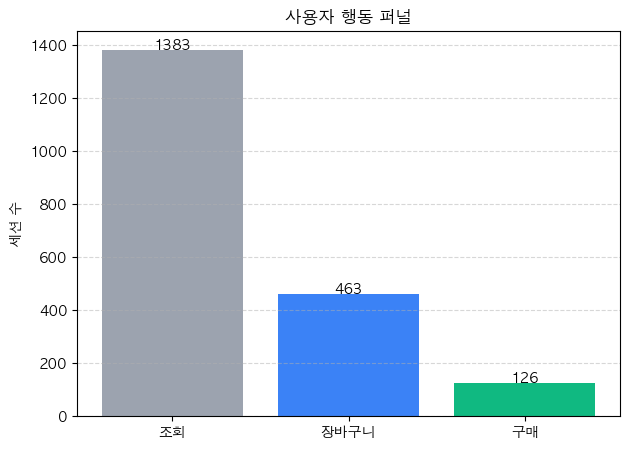

In [4]:
plt.figure(figsize=(7, 5))

funnel_stage = ["조회", "장바구니", "구매"]
funnel_count = [view_count, cart_count, purchase_count]

colors = ["#9CA3AF", "#3B82F6", "#10B981"]

bars = plt.bar(funnel_stage, funnel_count, color=colors)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center'
    )

plt.title("사용자 행동 퍼널")
plt.ylabel("세션 수")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

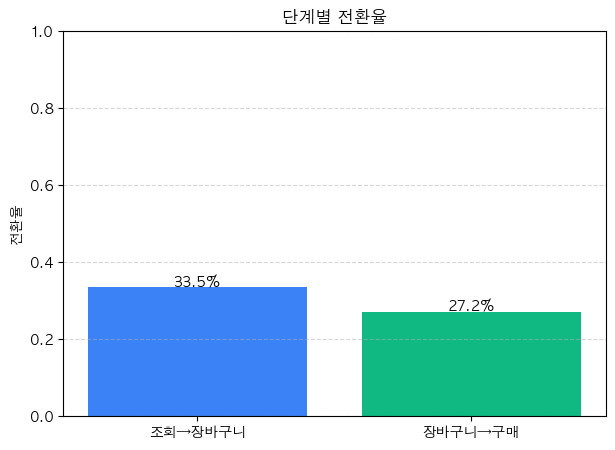

In [5]:
conversion_labels = ["조회→장바구니", "장바구니→구매"]
conversion_values = [
    cart_count / view_count,
    purchase_count / cart_count
]

colors = ["#3B82F6", "#10B981"]

plt.figure(figsize=(7, 5))
bars = plt.bar(conversion_labels, conversion_values, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1%}",
        ha='center'
    )

plt.title("단계별 전환율")
plt.ylabel("전환율")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

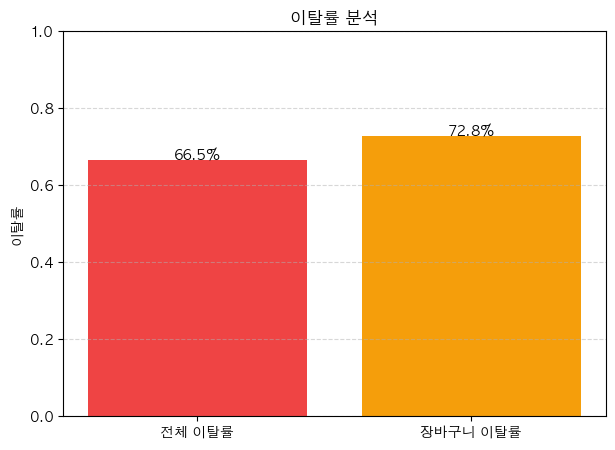

In [6]:
drop_labels = ["전체 이탈률", "장바구니 이탈률"]
drop_values = [
    bounce_rate,
    1 - (purchase_count / cart_count)
]

colors = ["#EF4444", "#F59E0B"]

plt.figure(figsize=(7, 5))
bars = plt.bar(drop_labels, drop_values, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1%}",
        ha='center'
    )

plt.title("이탈률 분석")
plt.ylabel("이탈률")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

/var/folders/z6/ftyb5wr90r741j34byrdw5c40000gn/T/ipykernel_21014/2930924471.py:70: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


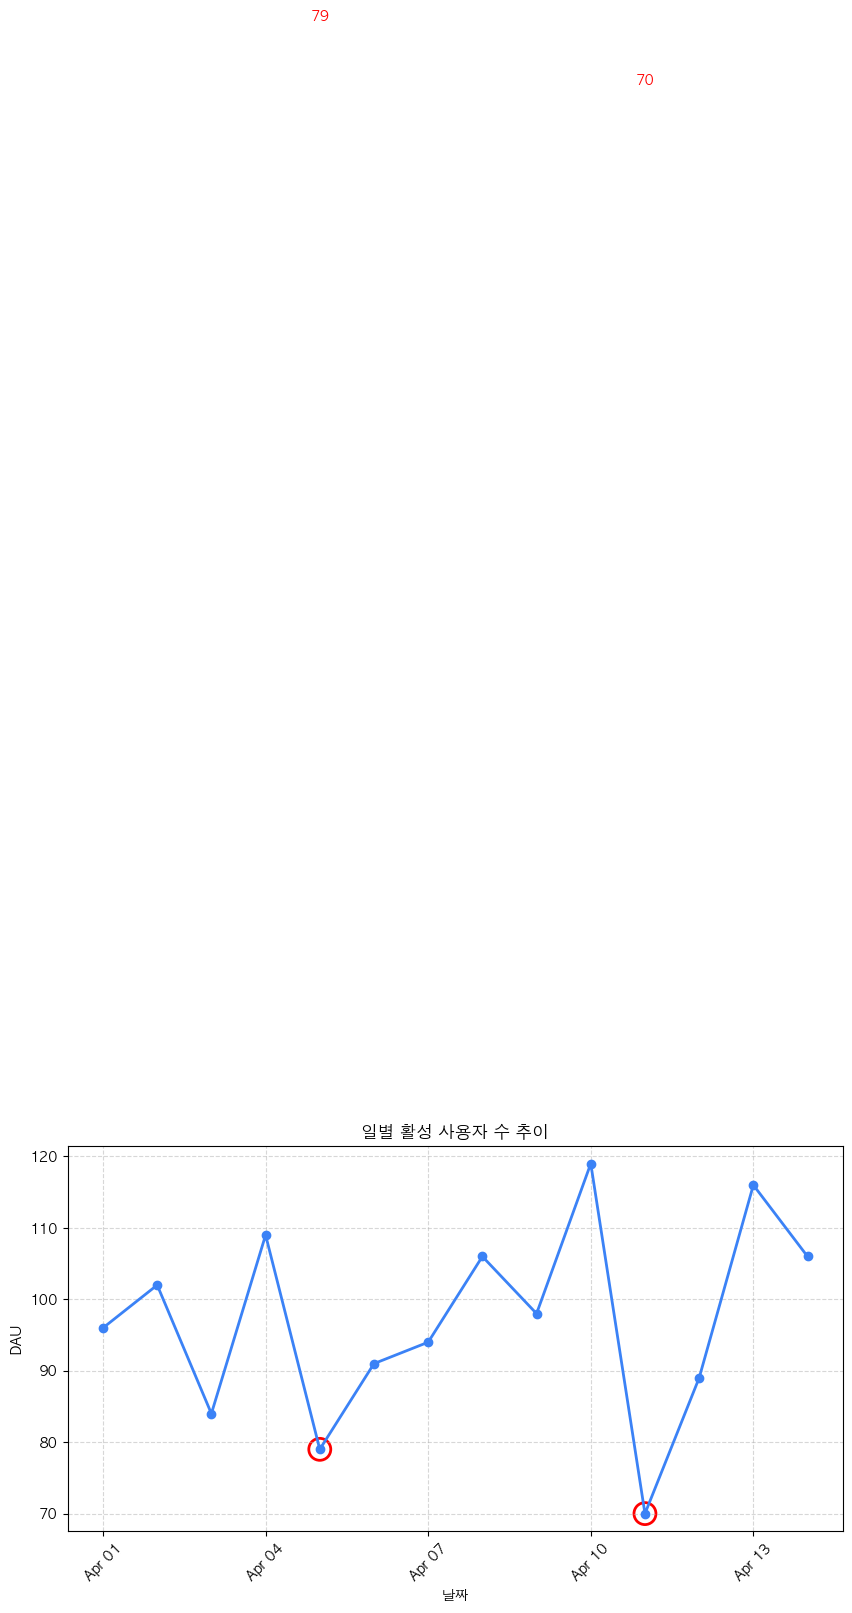

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# 데이터 불러오기
df = pd.read_csv("mju_mock_data_2132.csv")
df["event_time"] = pd.to_datetime(df["event_time"])
df["date"] = df["event_time"].dt.date

# DAU 계산
dau = df.groupby("date")["user_id"].nunique().reset_index()
dau["date"] = pd.to_datetime(dau["date"])

# =========================
# 하락 + 특정 값 이하만
# =========================
dau["diff"] = dau["user_id"].diff()

# 🔴 조건: 감소 + 80 이하
drop_points = dau[(dau["diff"] < 0) & (dau["user_id"] <= 80)]

# =========================
# 그래프
# =========================

fig, ax = plt.subplots(figsize=(10,5))

# 라인
ax.plot(dau["date"], dau["user_id"], marker="o", linewidth=2, color="#3B82F6")

# 조건 만족 지점 표시
ax.scatter(
    drop_points["date"],
    drop_points["user_id"],
    s=250,
    facecolors='none',
    edgecolors='red',
    linewidths=2
)

# 숫자 표시
for i in drop_points.index:
    ax.text(
        dau.loc[i, "date"],
        dau.loc[i, "user_id"] + 200,
        int(dau.loc[i, "user_id"]),
        fontsize=10,
        color="red",
        ha='center'
    )

# =========================
# 날짜 간격
# =========================
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.xticks(rotation=45)

# =========================

plt.title("일별 활성 사용자 수 추이")
plt.xlabel("날짜")
plt.ylabel("DAU")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()